<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/note_normalizing_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Normalizing Flow Models

參考:
- Stanford CS236: Deep Generative Models I 2023
  - [Lecture 7 - Normalizing Flows](https://www.youtube.com/watch?v=m6dKKRsZwBQ) (34:46~)
  - [Lecture 8 - Normalizing Flows](https://www.youtube.com/watch?v=qgTvgBCOyn8&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=8)
  - [Syllabus](https://deepgenerativemodels.github.io/syllabus.html)

#### Motivation

Map simple distributions to complex distributions through an invertible transformation.
- deterministic, invertible: $x=f_\theta(z), z=f_\theta^{-1}(x)$
- easily invert $p(x \mid z)$ and compute $p(z \mid x)$ by design

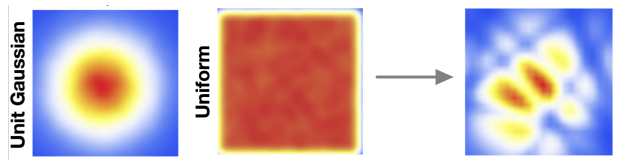

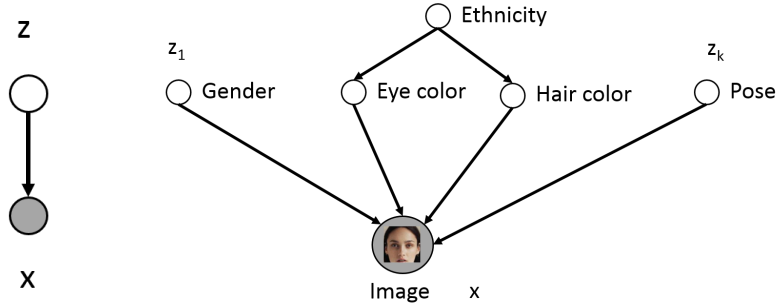

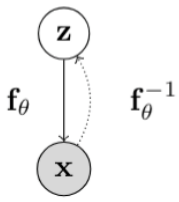

#### Generalized Change of Variables

*Theorem: Change of variables*

Let
- random variables: $Z, X$
- $f:\mathbb{R}^n \mapsto \mathbb{R}^n$
- $X=f(Z), Z=f^{-1}(X)$

Then
- $\displaystyle p_X(x)=p_Z\left( f^{-1}(x) \right) \left| \det \left( \frac{\partial f^{-1}(x)}{\partial x} \right) \right|=p_Z(z) \left| \det \left( \frac{\partial f(z)}{\partial z} \right) \right|^{-1}$

*Definition: jacobian matrix*
- $J = \frac{\partial f}{\partial z} =
\begin{bmatrix}
\frac{\partial f_1}{\partial z_1} & \cdots & \frac{\partial f_1}{\partial z_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_n}{\partial z_1} & \cdots & \frac{\partial f_n}{\partial z_n}
\end{bmatrix}$

#### Normalizing Flow

- normalizing: Change of variables gives a normalized density after
applying an invertible transformation
- flow: Invertible transformations can be composed with each other
- $f_\theta(z_0)=f_{\theta_m}^m \circ \dots \circ f_{\theta_1}^1(z_0)=z_m$
- $z_0 \sim \text{Gaussian}$
- $x=z_M$
- $\displaystyle p_X(x;\theta)=p_Z\left( f_\theta^{-1}(x) \right) \left| \det \left( \frac{\partial f_\theta^{-1}(x)}{\partial x} \right) \right|=p_Z \left( f_\theta^{-1}(x) \right) \prod_{m=1}^M\left| \det \left( \frac{\partial (f_\theta^m)^{-1}(z_m)}{\partial z_m} \right) \right|$

planar flows

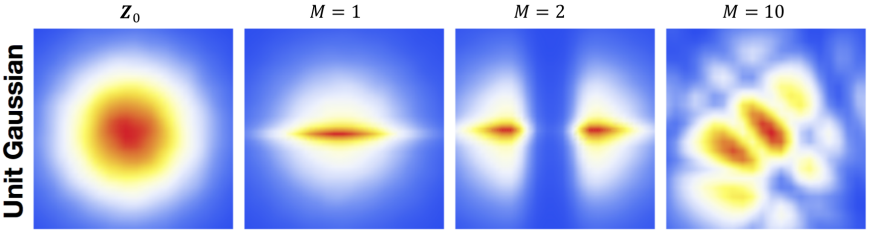

#### Learning and Inference

- likelihood evaluation via inverse tranformation $x \mapsto z$ and
change of variables formula
  - $\displaystyle \max\limits_\theta\ \log p_X(\mathcal{D};\theta)=\sum\limits_{x \in \mathcal{D}} \left( \log p_Z\left( f_\theta^{-1}(x) \right) + \log\ \left| \det \left( \frac{\partial f_\theta^{-1}(x)}{\partial x} \right) \right| \right)$
- sampling via forward transformation $z \mapsto x$
  - $z \sim p_Z(z)$
  - $x=f_\theta(z)$
- latent representations inferred via inverse transformation
  - $z=f_\theta^{-1}(x)$

- Invertible transformations with tractable evaluation:
  - Likelihood evaluation requires efficient evaluation of $x \mapsto z$ mapping
  - Sampling requires efficient evaluation of $z \mapsto x$ mapping
- Computing likelihoods also requires the evaluation of determinants of
$n \times n$ Jacobian matrices, where $n$ is the data dimensionality
  - the determinant of a triangular matrix is the product of the diagonal entries

#### Real-NVP

- forward mapping $z \mapsto x$:
  - $x_{1:d}=z_{1:d}$ (identity transformation)
  - $x_{d+1:n}=z_{d+1:n} \odot \exp \left( \alpha_\theta(z_{1:d}) \right) + \mu_\theta(z_{1:d})$
  - $\mu_\theta(\cdot)$ and $\alpha_\theta(\cdot)$ are both neural networks with parameters $\theta$, $d$ input units, and $n − d$ output units

- inverse mapping $x \mapsto z$:
  - $z_{1:d}=x_{1:d}$ (identity transformation)
  - $z_{d+1:n}=\left( x_{d+1:n} - \mu_\theta(x_{1:d}) \right) \odot \exp \left( -\alpha_\theta(z_{1:d}) \right)$

- Jacobian of forward mapping:
  - $\displaystyle J=\frac{\partial x}{\partial z}=\begin{bmatrix}
I_d & 0 \\
\displaystyle \frac{\partial x_{d+1:n}}{\partial z_{1:d}} & \text{diag} \left( \exp \left( \alpha_\theta(z_{1:d}) \right) \right)
\end{bmatrix}$
  - $\displaystyle \det(J)=\prod_{i=d+1}^n \exp \left( \alpha_\theta(z_{1:d})_i \right)=\exp \left( \sum_{i=d+1}^n \alpha_\theta(z_{1:d})_i \right)$

samples generated:

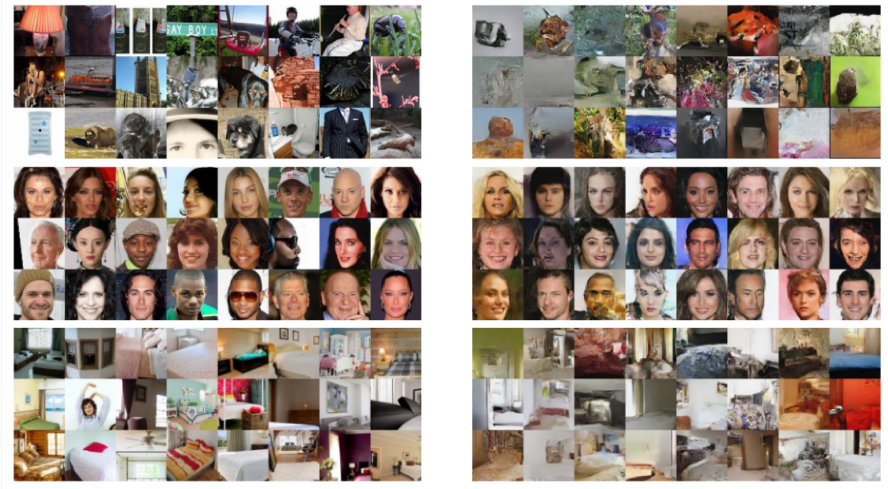